# 02 - Image Preprocessing Pipeline

Interactive exploration of the preprocessing pipeline that runs before OCR.

In [1]:
import sys

sys.path.insert(0, '..')

import cv2
import matplotlib.pyplot as plt

from ocr_manga_title.config import load_config, load_preprocess_config
from ocr_manga_title.preprocess import PreProcessingPipeline

config = load_config('../configs.toml')
pp_config = load_preprocess_config('../preprocess.yaml')
pipeline = PreProcessingPipeline(pp_config, config.images_path)
print(f'Preprocessing enabled: {pp_config["preprocessing"]["enabled"]}')
print(f'Debug mode: {pp_config["preprocessing"].get("debug", False)}')
print(f'Steps: {[s.name for s in pipeline._steps]}')

Preprocessing enabled: True
Debug mode: True
Steps: ['roi', 'grayscale', 'upscale', 'denoise', 'binarize']


## Section 1: Load & Display Original Image

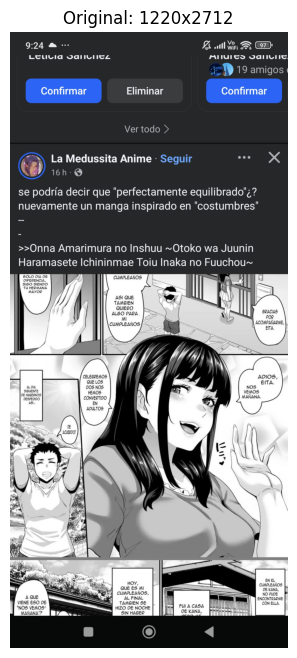

In [2]:
image_path = "/Users/rconsuegra/Pictures/images/Screenshot_2026-03-22-09-24-57-281_com.facebook.katana.jpg"
img = cv2.imread(image_path)
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.title(f'Original: {img.shape[1]}x{img.shape[0]}')
    plt.axis('off')
    plt.show()
else:
    print('Image not found. Update image_path variable.')

## Section 2: Individual Step Exploration

Grayscale: {'original_channels': 3, 'converted': True}
ROI: {'method': 'contour', 'regions_detected': 148, 'regions_merged': 1, 'crop_performed': False, 'reason': 'coverage_too_large', 'coverage': 0.974}


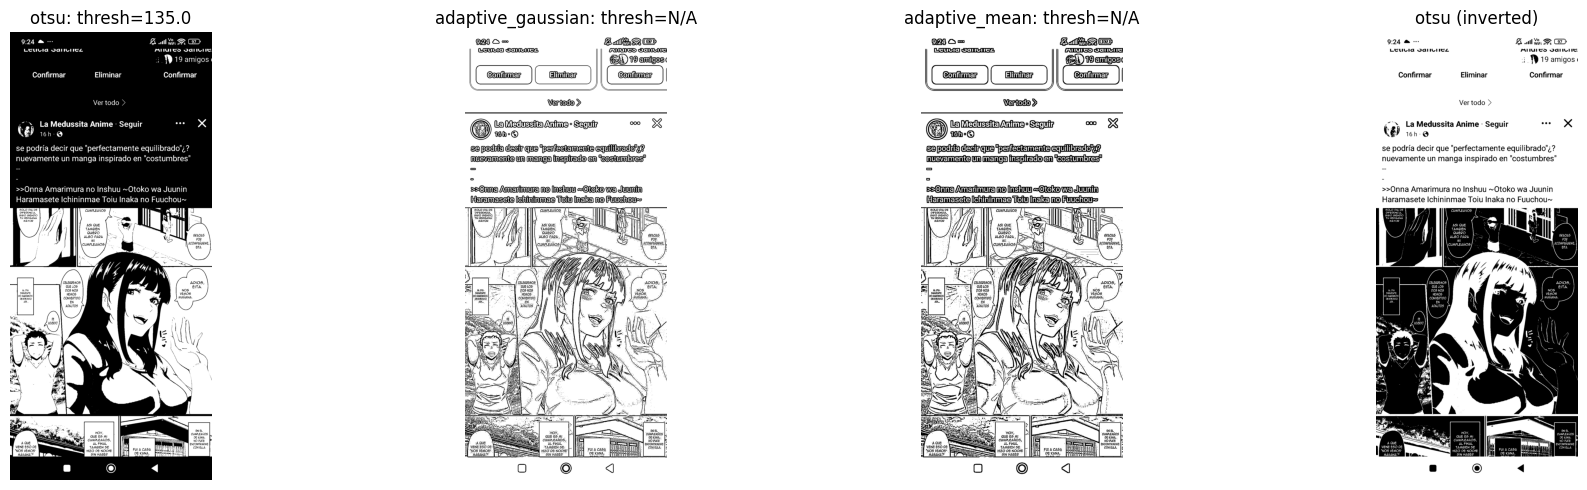

In [3]:
from ocr_manga_title.preprocess.steps.binarize import BinarizeStep
from ocr_manga_title.preprocess.steps.grayscale import GrayscaleStep
from ocr_manga_title.preprocess.steps.roi import ROIStep
from ocr_manga_title.preprocess.steps.upscale import UpscaleStep

if img is not None:
    # Grayscale
    gray_step = GrayscaleStep()
    gray_img, gray_meta = gray_step.process(img, {})
    print(f'Grayscale: {gray_meta}')

    # ROI
    roi_step = ROIStep()
    roi_img, roi_meta = roi_step.process(img, {"method": "contour", "min_area": 100})
    print(f'ROI: {roi_meta}')

    # Binarize (on grayscale)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for i, method in enumerate(["otsu", "adaptive_gaussian", "adaptive_mean"]):
        bin_step = BinarizeStep()
        binary, meta = bin_step.process(gray_img, {"method": method})
        axes[i].imshow(binary, cmap='gray')
        axes[i].set_title(f'{method}: thresh={meta.get("threshold", "N/A")}')
        axes[i].axis('off')

    # Inverted
    bin_step = BinarizeStep()
    inv, inv_meta = bin_step.process(gray_img, {"method": "otsu", "invert": True})
    axes[3].imshow(inv, cmap='gray')
    axes[3].set_title('otsu (inverted)')
    axes[3].axis('off')
    plt.tight_layout()
    plt.show()

## Section 3: Upscaling Comparison

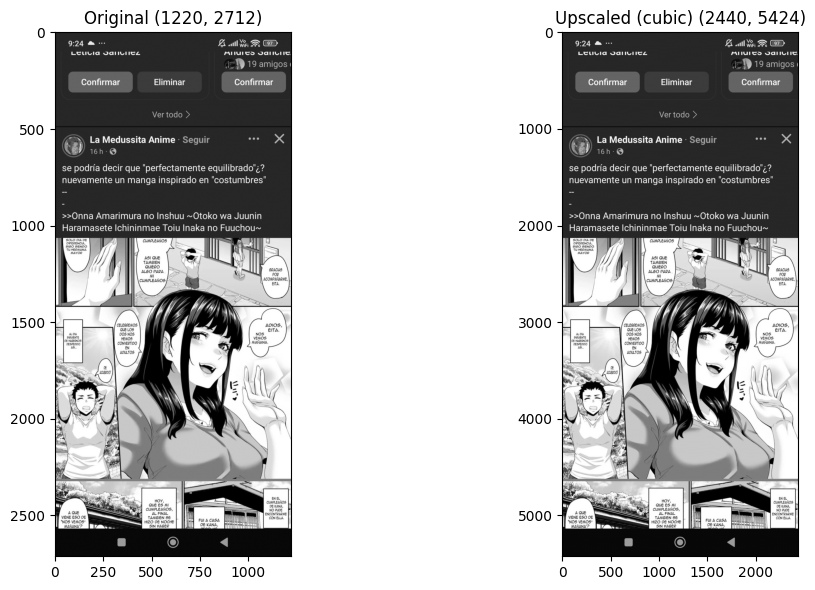

In [4]:
if img is not None:
    up_step = UpscaleStep()
    result, meta = up_step.process(gray_img, {"method": "cubic", "scale_factor": 2})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    ax1.imshow(gray_img, cmap='gray')
    ax1.set_title(f'Original {meta["input_size"]}')
    ax2.imshow(result, cmap='gray')
    ax2.set_title(f'Upscaled (cubic) {meta["output_size"]}')
    plt.tight_layout()
    plt.show()

## Section 4: Full Pipeline Before/After

Steps: 5
Total time: 542ms
  roi: enabled=True, success=True, time=54ms
  grayscale: enabled=True, success=True, time=0ms
  upscale: enabled=True, success=True, time=3ms
  denoise: enabled=True, success=True, time=4ms
  binarize: enabled=True, success=True, time=12ms


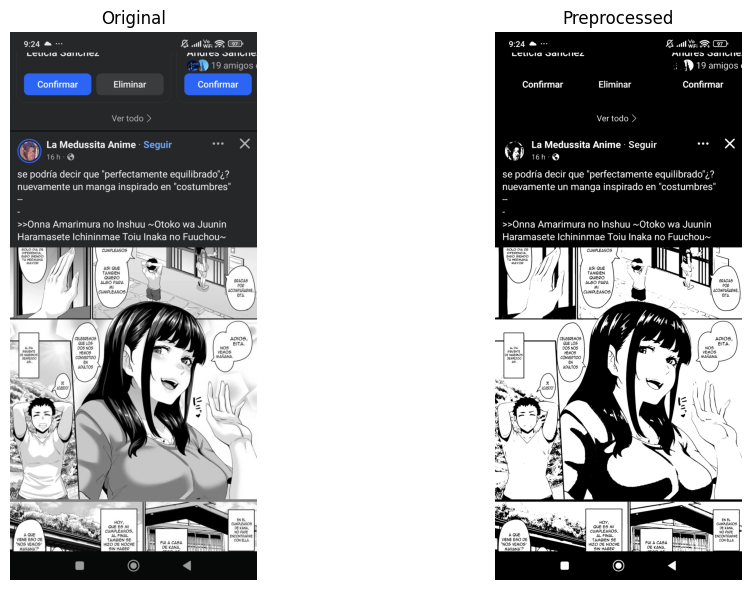

In [5]:
if img is not None:
    result = pipeline.process(image_path)
    print(f'Steps: {len(result.steps)}')
    print(f'Total time: {result.total_processing_time_ms}ms')
    for step in result.steps:
        print(f'  {step.step_name}: enabled={step.enabled}, success={step.success}, time={step.processing_time_ms}ms')

    if result.output_path:
        pp_img = cv2.imread(result.output_path)
        pp_img_rgb = cv2.cvtColor(pp_img, cv2.COLOR_BGR2RGB)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        ax1.imshow(img_rgb)
        ax1.set_title('Original')
        ax1.axis('off')
        ax2.imshow(pp_img_rgb)
        ax2.set_title('Preprocessed')
        ax2.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print('No preprocessed output (debug mode may be off or all steps disabled)')

## Section 5: OCR Comparison (with/without preprocessing)

In [6]:
from ocr_manga_title.config import load_config, load_ocr_config, load_preprocess_config
from ocr_manga_title.engine import OCREngine

if img is not None:
    config = load_config('../configs.toml')
    ocr_config = load_ocr_config('../ocrs.yaml')

    # Without preprocessing
    engine_no_pp = OCREngine(config, ocr_config)
    result_no_pp = engine_no_pp.process(image_path)

    # With preprocessing
    pp_config = load_preprocess_config('../preprocess.yaml')
    engine_with_pp = OCREngine(config, ocr_config, pp_config)
    result_with_pp = engine_with_pp.process(image_path)

    print('=== Without Preprocessing ===')
    print(f'Extracted: {result_no_pp.ocr_results}')
    print()
    print('=== With Preprocessing ===')
    print(f'Extracted: {result_with_pp.ocr_results}')
    if result_with_pp.preprocess_result:
        for step in result_with_pp.preprocess_result.steps:
            print(f'  {step.step_name}: {step.processing_time_ms}ms')

Authentication error: Error code: 401 - {'error': {'message': 'Missing Authentication header', 'code': 401}}
Authentication error: Error code: 401 - {'error': {'message': 'Missing Authentication header', 'code': 401}}


=== Without Preprocessing ===
Extracted: [OCRResult(raw_text='9:24 @&--- BK tl vic E GD LUTULIA VUAIHVULIITZ FALIULTS の GlulI ピ ビ (i -y 19 amigos | Confirmar Eliminar Confirmar Ver todo > 。 。 ふ ) La Medussita Anime - Seguir … XK M の 16n. く se podria decir que "perfectamente equilibradoz? nuevamente un manga inspirado en "costumbres" >>Onna Amarimura no Inshuu ~Otoko wa Juunin Haramasete Ichininmae Toiu Inaka no Fuuchou~ rom of eeANO5 / に | SIO SIENDO / | て TU HEoAANA MAYOR ASI QUE TAMBIEN QUIERO . ALGO PARA. | ~> MI シン CELEBREMOS QUE LOS 1586E000 CONVERTIOO ASI. EN ADLLT05 HOY, QUE ES MI 4 CUMPLEANOS, = AL FINAL VIENE ESO OE TAMBIEN SE "NOS VEMOS" Ry HIZO PE NOCHE AANANA や SIN HABER', model_name='tesseract', confidence=0.7954807692307692, processing_time_ms=2585, error=None)]

=== With Preprocessing ===
Extracted: [OCRResult(raw_text='9:24 @ ぬ … K wal Xo, CD LSeuVid VaAIIVIiIta FAILIULCS OUaALlIVvIiitt. i NY 19 amigos | Confirmar Eliminar Confirmar Ver todo > ~*~ La Medussita Anime - S